## Students Success Predictor


#### Data Loading

In [3]:
## Students Success Predictor

import pandas as pd

# Load dataset
df = pd.read_csv(r"Student_dataset.csv")

print("Sample Rows")
print(df.head())

print("\nDataset Shape")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\nDataset Info")
df.info()   # info() already prints, no need to use print()

print("\nSummary Statistics")
print(df.describe(include='all'))

print("\nMissing Values")
print(df.isnull().sum())


Sample Rows
   StudyHours  Attendance  PastScore Internet Passed  SleepHours
0           2          60         40      Yes     No           5
1           5          80         60       No    Yes           6
2           8          90         75      Yes    Yes           8
3           3          70         50      Yes     No           5
4           7          85         70       No    Yes           7

Dataset Shape
Rows: 20, Columns: 6

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   StudyHours  20 non-null     int64 
 1   Attendance  20 non-null     int64 
 2   PastScore   20 non-null     int64 
 3   Internet    20 non-null     object
 4   Passed      20 non-null     object
 5   SleepHours  20 non-null     int64 
dtypes: int64(4), object(2)
memory usage: 1.1+ KB

Summary Statistics
        StudyHours  Attendance  PastScore Internet Passe

#### Data handling

In [6]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv(r"Student_dataset.csv")

print("Missig values in each colums")
print(df.isnull().sum())

le = LabelEncoder()
df['Internet'] = le.fit_transform(df['Internet'])
df['Passed'] = le.fit_transform(df['Passed'])

print("After Encoding")
print(df.head())

print("data-types after cleaning")
print(df.dtypes)



Missig values in each colums
StudyHours    0
Attendance    0
PastScore     0
Internet      0
Passed        0
SleepHours    0
dtype: int64
After Encoding
   StudyHours  Attendance  PastScore  Internet  Passed  SleepHours
0           2          60         40         1       0           5
1           5          80         60         0       1           6
2           8          90         75         1       1           8
3           3          70         50         1       0           5
4           7          85         70         0       1           7
data-types after cleaning
StudyHours    int64
Attendance    int64
PastScore     int64
Internet      int64
Passed        int64
SleepHours    int64
dtype: object


#### Feature Scaling

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



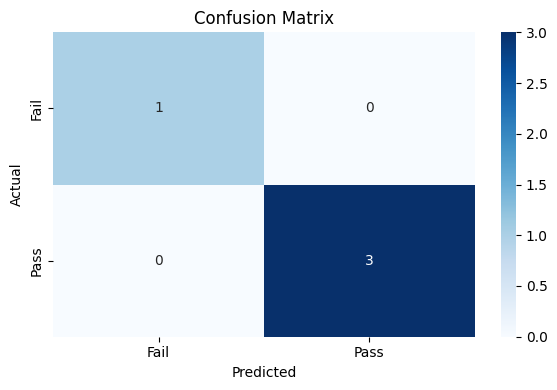

------ Predict Your Result ------
Prediction based on input: Fail


In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Student_dataset.csv")

# Encode categorical columns
le = LabelEncoder()
df['Internet'] = le.fit_transform(df['Internet'])
df['Passed'] = le.fit_transform(df['Passed'])

# Features & target
features = ["StudyHours", "Attendance", "PastScore", "SleepHours"]
X = df[features]
y = df['Passed']

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Model training
model = LogisticRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("Classification Report")
print(classification_report(y_test, y_pred))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# User prediction
print("------ Predict Your Result ------")

try:
    study_hours = float(input("Enter study hours: "))
    attendance = float(input("Enter attendance: "))
    past_score = float(input("Enter past score: "))
    sleep_hours = float(input("Enter sleep hours: "))

    user_input = pd.DataFrame([[study_hours, attendance, past_score, sleep_hours]],
                              columns=features)

    user_input_scaled = scaler.transform(user_input)

    prediction = model.predict(user_input_scaled)[0]

    result = "Pass" if prediction == 1 else "Fail"
    print(f"Prediction based on input: {result}")

except Exception as e:
    print("An error occurred:", e)
